# Temporal IM-Loss SNN Colab Runner

This notebook is the Colab control panel for the temporal SNN experiments. It does not reimplement the model or training loop. It calls the repository scripts so the command-line workflow remains the source of truth.

Main workflow:

1. Load the repo from a Drive zip or Git URL.
2. Install dependencies and verify GPU/PyTorch.
3. Run quick Randman checks.
4. Run the three-condition Randman comparison.
5. Summarize accuracy, losses, spike diagnostics, and plots.
6. Run the output-layer IM lambda sweep.
7. Optionally switch to SHD after placing SHD data in Drive.

Core comparison:

- Non-spiking output with max membrane readout.
- Spiking output counted over time.
- Spiking output counted over time with output-layer IM loss.

## 1. Imports And Helpers

Run this first. The `run(...)` helper executes repository commands and stops the notebook if a command fails.

In [2]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import textwrap

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None
from IPython.display import Image, display


def run(args, env=None, cwd=None):
    args = [str(arg) for arg in args]
    print("$", " ".join(args))
    subprocess.run(args, check=True, env=env, cwd=cwd)


def read_csv(path):
    global pd
    if pd is None:
        import pandas as pd
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_image(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))


## 2. Repository Setup

For a private repo where you do not own the GitHub permissions, the safest path is a Drive zip. Upload a zip of the repo to Drive, excluding `.venv/`, `runs/`, and large dataset files.

If you already manually unzipped the repo and `%cd`'d into it, this cell will reuse the current folder.

In [3]:
ZIP_PATH = Path("/content/drive/MyDrive/IM-Loss-Temporal-SNN.zip")
REPO_URL = "https://github.com/MuHe03/IM-Loss-Temporal-SNN"  # Optional. Leave empty for private-repo zip workflow.
REPO_DIR = Path("/content/IM-Loss-Temporal-SNN")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print("Drive mount skipped or unavailable:", exc)

if Path("train_temporal.py").exists():
    REPO_DIR = Path.cwd()
    print("Using current repository:", REPO_DIR)
elif ZIP_PATH.exists():
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    run(["unzip", "-q", ZIP_PATH, "-d", "/content"])
    if not (REPO_DIR / "train_temporal.py").exists():
        candidates = sorted(Path("/content").glob("**/train_temporal.py"))
        if not candidates:
            raise RuntimeError("Could not find train_temporal.py after unzipping.")
        REPO_DIR = candidates[0].parent
    os.chdir(REPO_DIR)
    print("Unzipped repository:", Path.cwd())
elif REPO_URL:
    if not REPO_DIR.exists():
        run(["git", "clone", REPO_URL, REPO_DIR])
    os.chdir(REPO_DIR)
    run(["git", "pull", "--ff-only"])
    print("Cloned repository:", Path.cwd())
else:
    raise RuntimeError(
        "No repo found. Upload ZIP_PATH to Drive, set REPO_URL, or cd into the repo."
    )

required = ["train_temporal.py", "models/temporal_snn.py", "data/randman.py", "scripts/run_temporal_task.py"]
missing = [path for path in required if not Path(path).exists()]
if missing:
    raise RuntimeError(f"Repository is incomplete; missing: {missing}")

print("repo:", Path.cwd())
print("top-level files:")
print("\n".join(sorted(path.name for path in Path.cwd().iterdir())[:30]))


Mounted at /content/drive
$ git clone https://github.com/MuHe03/IM-Loss-Temporal-SNN /content/IM-Loss-Temporal-SNN
$ git pull --ff-only
Cloned repository: /content/IM-Loss-Temporal-SNN
repo: /content/IM-Loss-Temporal-SNN
top-level files:
.git
.gitattributes
.gitignore
README.md
data
datasets
eval_temporal.py
models
notebooks
requirements.txt
scripts
summarize_ff_output_3way.py
summarize_lambda_sweep.py
summarize_shd_results.py
train_temporal.py


## 3. Install And Runtime Check

This verifies that PyTorch, CUDA, and the CLI entry points are available.

In [4]:
run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

import torch

print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

run([sys.executable, "train_temporal.py", "--help"])
run([sys.executable, "eval_temporal.py", "--help"])


$ /usr/bin/python3 -m pip install -r requirements.txt
python: 3.12.13
torch: 2.11.0+cu128
cuda available: True
gpu: Tesla T4
$ /usr/bin/python3 train_temporal.py --help
$ /usr/bin/python3 eval_temporal.py --help


## 4. Persistent Output Directory And Default Settings

Colab local disk is temporary. Keep checkpoints, CSV files, JSON files, and plots in Drive through `RUNS_ROOT`.

The defaults below target Randman. SHD is configured later in its own section.

In [5]:
RUNS_ROOT = "/content/drive/MyDrive/im_snn_runs"
Path(RUNS_ROOT).mkdir(parents=True, exist_ok=True)

os.environ.update({
    "RUNS_ROOT": RUNS_ROOT,
    "DATASET": "Randman",
    "DATA_ROOT": "datasets/SHD",
    "EPOCHS": "20",
    "BATCH_SIZE": "64",
    "NUM_WORKERS": "2",
    "HIDDEN_SIZE": "256",
    "NUM_LAYERS": "1",
    "READOUT": "max_membrane",
    "LEARNING_RATE": "0.001",
})

if torch.cuda.is_available():
    os.environ.pop("NO_CUDA", None)
else:
    os.environ["NO_CUDA"] = "1"

print("RUNS_ROOT:", RUNS_ROOT)
print("NO_CUDA:", os.environ.get("NO_CUDA", "0"))
print("key settings:")
for key in ["DATASET", "EPOCHS", "BATCH_SIZE", "NUM_WORKERS", "HIDDEN_SIZE", "READOUT", "LEARNING_RATE"]:
    print(f"  {key}={os.environ.get(key)}")


RUNS_ROOT: /content/drive/MyDrive/im_snn_runs
NO_CUDA: 0
key settings:
  DATASET=Randman
  EPOCHS=20
  BATCH_SIZE=64
  NUM_WORKERS=2
  HIDDEN_SIZE=256
  READOUT=max_membrane
  LEARNING_RATE=0.001


## 5. Task Runner Helpers

These helpers call `scripts/run_temporal_task.py`. They are useful for dry-runs, partial tests, and full experiment grids.

In [6]:
def run_task(suite, task_id, dry_run=False):
    cmd = [sys.executable, "scripts/run_temporal_task.py", suite, int(task_id)]
    if dry_run:
        cmd.append("--dry-run")
    run(cmd)


def run_tasks(suite, task_ids, dry_run=False):
    task_ids = list(task_ids)
    print(f"Running {len(task_ids)} task(s) for {suite}: {task_ids}")
    for task_id in task_ids:
        run_task(suite, task_id, dry_run=dry_run)


print("Dry-run examples:")
run_task("ff_output_3way", 0, dry_run=True)
run_task("ff_output_lambda_sweep", 0, dry_run=True)


Dry-run examples:
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 0 --dry-run
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 0 --dry-run


## 6. Quick Sanity Checks

Run this before expensive experiments. It checks the model stack and does a one-batch Randman train/eval pass.

In [10]:
run([sys.executable, "scripts/smoke_temporal.py"])
run([
    sys.executable,
    "train_temporal.py",
    "--dataset", "Randman",
    "--output_dir", str(Path(RUNS_ROOT) / "_checks" / "quick_randman"),
    "--epochs", "1",
    "--max_train_batches", "1",
    "--max_eval_batches", "1",
    "--num_workers", "0",
])


$ /usr/bin/python3 scripts/smoke_temporal.py
$ /usr/bin/python3 train_temporal.py --dataset Randman --output_dir /content/drive/MyDrive/im_snn_runs/_checks/quick_randman --epochs 1 --max_train_batches 1 --max_eval_batches 1 --num_workers 0


## 7. Randman Three-Condition Comparison

This is the primary small benchmark.

Task groups:

- `0-4`: non-spiking max membrane baseline.
- `5-9`: spiking output count.
- `10-14`: spiking output count + rate IM.

Start with one seed using `[0, 5, 10]`. If it works, set `FULL_THREE_WAY=True` to run all 15 tasks.

In [7]:
FULL_THREE_WAY = True

three_way_tasks = range(15) if FULL_THREE_WAY else [0, 5, 10]
run_tasks("ff_output_3way", three_way_tasks)


Running 15 task(s) for ff_output_3way: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 0
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 1
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 2
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 3
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 4
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 5
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 6
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 7
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 8
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 9
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 10
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 11
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 12
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way

## 8. Summarize Randman Three-Condition Runs

This creates CSV, JSON, and a bar plot. Use `--allow_partial` for the one-seed quick run; omit it for the full 5-seed run.

$ /usr/bin/python3 summarize_ff_output_3way.py --dataset Randman --run_root /content/drive/MyDrive/im_snn_runs --output_dir /content/drive/MyDrive/im_snn_runs/summary


,setting,setting_label,n,mean_test_acc_percent,std_test_acc_percent,min_test_acc_percent,max_test_acc_percent,seed_test_acc_percent
0,lif_mlp_noim,Non-spiking membrane,5,83.203125,3.569466,79.296875,88.671875,83.5938;79.2969;80.8594;83.5938;88.6719
1,spiking_count,Spiking output count,5,83.906250,1.277768,82.031250,85.546875,84.3750;82.0312;83.5938;83.9844;85.5469
2,spiking_count_im,Spiking output count + IM,5,85.859375,2.382492,83.984375,89.453125,87.1094;83.9844;84.7656;83.9844;89.4531


,setting,setting_label,seed,output_mode,readout,use_im_loss_train,im_include_output_train,im_loss_weight_train,im_hidden_weight_train,im_output_weight_train,...,test_firing_rate_layer_0,test_firing_rate_output,test_entropy_output,test_no_output_spike_fraction,test_output_spike_count_mean,test_correct_class_output_spike_count_mean,test_max_competing_output_spike_count_mean,test_correct_output_gt_competing_fraction,checkpoint,eval_json
0,lif_mlp_noim,Non-spiking membrane,2020,nonspiking,max_membrane,False,False,0.001,1.0,1.0,...,0.067871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/im_snn_runs/randman/ff_...,/content/drive/MyDrive/im_snn_runs/randman/ff_...
1,lif_mlp_noim,Non-spiking membrane,42,nonspiking,max_membrane,False,False,0.001,1.0,1.0,...,0.063027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/im_snn_runs/randman/ff_...,/content/drive/MyDrive/im_snn_runs/randman/ff_...
2,lif_mlp_noim,Non-spiking membrane,123,nonspiking,max_membrane,False,False,0.001,1.0,1.0,...,0.050073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/im_snn_runs/randman/ff_...,/content/drive/MyDrive/im_snn_runs/randman/ff_...
3,lif_mlp_noim,Non-spiking membrane,309,nonspiking,max_membrane,False,False,0.001,1.0,1.0,...,0.060071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/im_snn_runs/randman/ff_...,/content/drive/MyDrive/im_snn_runs/randman/ff_...
4,lif_mlp_noim,Non-spiking membrane,969,nonspiking,max_membrane,False,False,0.001,1.0,1.0,...,0.072394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/im_snn_runs/randman/ff_...,/content/drive/MyDrive/im_snn_runs/randman/ff_...


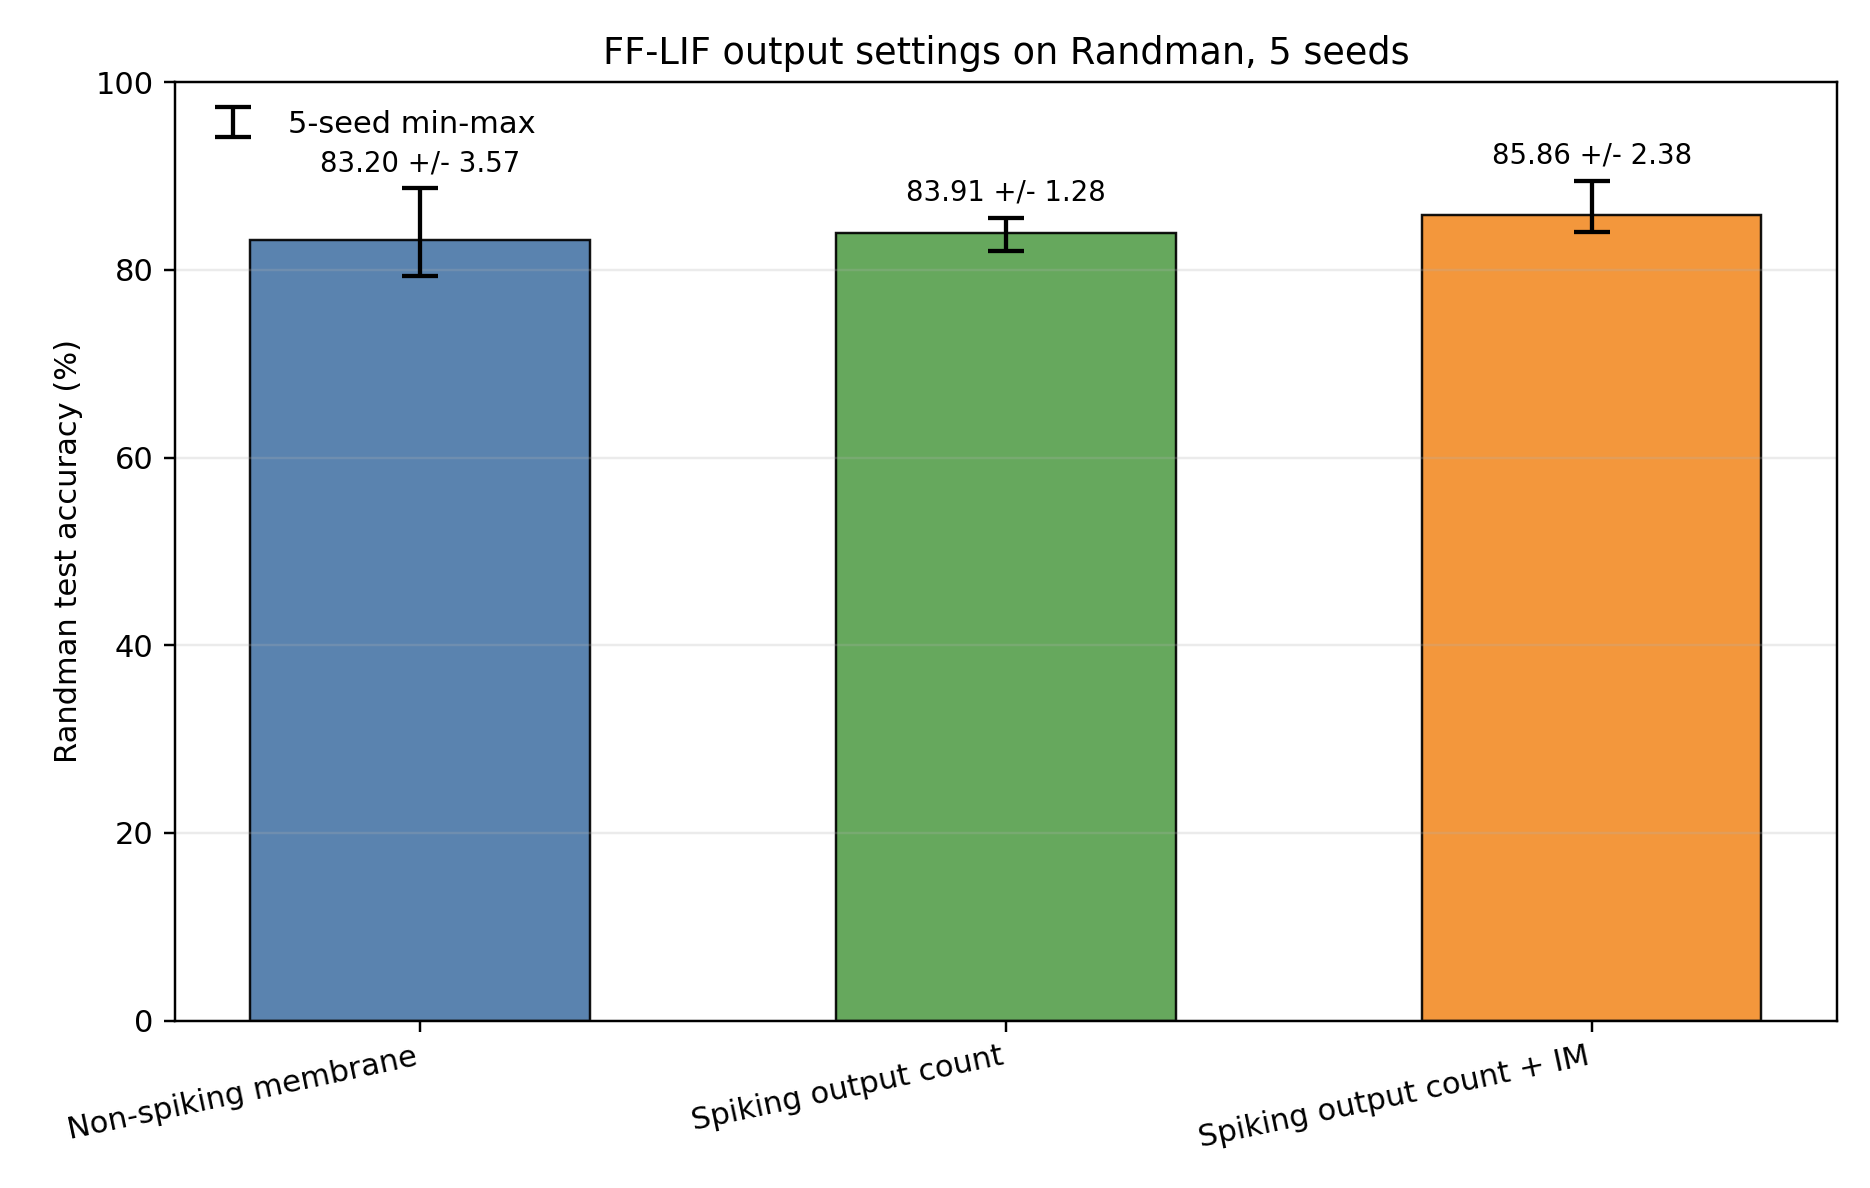

In [8]:
summary_dir = Path(RUNS_ROOT) / "summary"
summary_dir.mkdir(parents=True, exist_ok=True)

summary_cmd = [
    sys.executable,
    "summarize_ff_output_3way.py",
    "--dataset", "Randman",
    "--run_root", RUNS_ROOT,
    "--output_dir", summary_dir,
]
if not FULL_THREE_WAY:
    summary_cmd.append("--allow_partial")
run(summary_cmd)

randman_summary_csv = summary_dir / "randman_ff_output_3way_summary.csv"
randman_detail_csv = summary_dir / "randman_ff_output_3way_test_eval.csv"
display(read_csv(randman_summary_csv))
display(read_csv(randman_detail_csv).head())
show_image(summary_dir / "randman_ff_output_3way_hist.png")


## 8b. Randman Report Figures And Diagnostic Tables
Build report-ready figures from the three-condition summary files: accuracy with uncertainty, output activity diagnostics, and correct-vs-competing output spike evidence.

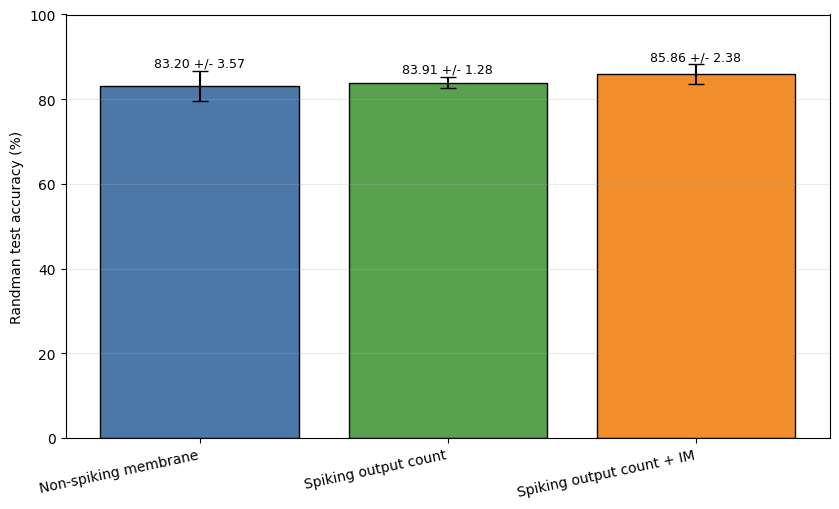

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_report_3way_accuracy.png


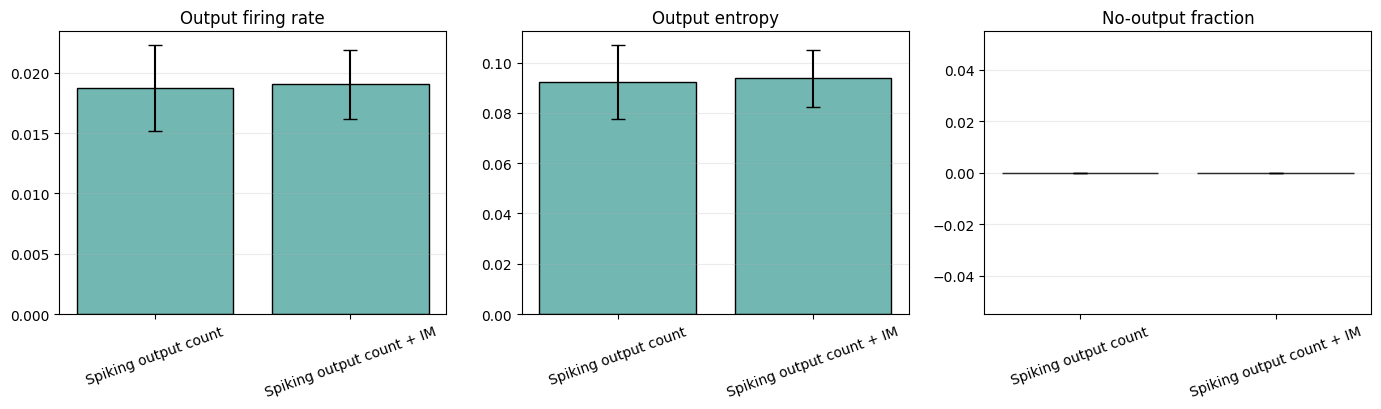

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_report_output_diagnostics.png


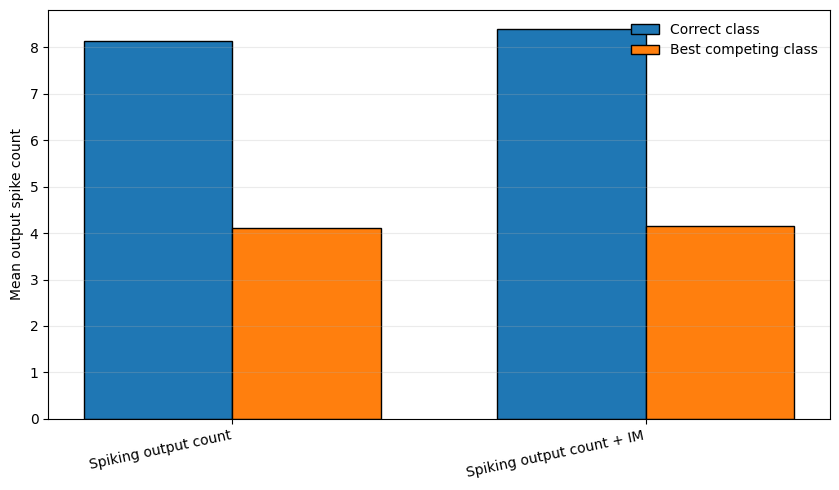

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_report_correct_vs_competing_spikes.png


[{'setting': 'lif_mlp_noim',
  'setting_label': 'Non-spiking membrane',
  'n': '5',
  'mean_test_acc_percent': '83.203125',
  'std_test_acc_percent': '3.569466187987708',
  'min_test_acc_percent': '79.296875',
  'max_test_acc_percent': '88.671875',
  'seed_test_acc_percent': '83.5938;79.2969;80.8594;83.5938;88.6719'},
 {'setting': 'spiking_count',
  'setting_label': 'Spiking output count',
  'n': '5',
  'mean_test_acc_percent': '83.90625',
  'std_test_acc_percent': '1.2777677526403224',
  'min_test_acc_percent': '82.03125',
  'max_test_acc_percent': '85.546875',
  'seed_test_acc_percent': '84.3750;82.0312;83.5938;83.9844;85.5469'},
 {'setting': 'spiking_count_im',
  'setting_label': 'Spiking output count + IM',
  'n': '5',
  'mean_test_acc_percent': '85.859375',
  'std_test_acc_percent': '2.3824922940588915',
  'min_test_acc_percent': '83.984375',
  'max_test_acc_percent': '89.453125',
  'seed_test_acc_percent': '87.1094;83.9844;84.7656;83.9844;89.4531'}]

In [9]:
import csv
import math
from statistics import mean

import matplotlib.pyplot as plt


def read_csv_rows(path):
    path = Path(path)
    if not path.exists():
        print("missing:", path)
        return []
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))


def to_float(value, default=math.nan):
    try:
        if value == "" or value is None:
            return default
        return float(value)
    except (TypeError, ValueError):
        return default


def save_current_figure(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.show()
    print("wrote", path)


summary_dir = Path(RUNS_ROOT) / "summary"
randman_summary_csv = summary_dir / "randman_ff_output_3way_summary.csv"
randman_detail_csv = summary_dir / "randman_ff_output_3way_test_eval.csv"
summary_rows = read_csv_rows(randman_summary_csv)
detail_rows = read_csv_rows(randman_detail_csv)

if summary_rows:
    labels = [row["setting_label"] for row in summary_rows]
    means = [to_float(row["mean_test_acc_percent"]) for row in summary_rows]
    stds = [to_float(row["std_test_acc_percent"], 0.0) for row in summary_rows]

    plt.figure(figsize=(8.5, 5.2))
    plt.bar(labels, means, yerr=stds, capsize=6, color=["#4c78a8", "#59a14f", "#f28e2b"], edgecolor="black")
    plt.ylabel("Randman test accuracy (%)")
    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=12, ha="right")
    for x, (m, s) in enumerate(zip(means, stds)):
        plt.text(x, min(99, m + s + 1.0), f"{m:.2f} +/- {s:.2f}", ha="center", fontsize=9)
    save_current_figure(summary_dir / "randman_report_3way_accuracy.png")

if detail_rows:
    spiking_rows = [row for row in detail_rows if row.get("output_mode") == "spiking_count"]
    diagnostic_keys = [
        ("test_firing_rate_output", "Output firing rate"),
        ("test_entropy_output", "Output entropy"),
        ("test_no_output_spike_fraction", "No-output fraction"),
    ]
    settings = []
    for row in spiking_rows:
        if row["setting_label"] not in settings:
            settings.append(row["setting_label"])

    if settings:
        fig, axes = plt.subplots(1, len(diagnostic_keys), figsize=(14, 4.2))
        for ax, (key, title) in zip(axes, diagnostic_keys):
            values = []
            errors = []
            for setting in settings:
                vals = [to_float(row.get(key)) for row in spiking_rows if row["setting_label"] == setting]
                vals = [v for v in vals if not math.isnan(v)]
                values.append(mean(vals) if vals else math.nan)
                errors.append(0.0 if len(vals) <= 1 else (sum((v - mean(vals)) ** 2 for v in vals) / (len(vals) - 1)) ** 0.5)
            ax.bar(settings, values, yerr=errors, capsize=5, color="#72b7b2", edgecolor="black")
            ax.set_title(title)
            ax.grid(axis="y", alpha=0.25)
            ax.tick_params(axis="x", rotation=20)
        save_current_figure(summary_dir / "randman_report_output_diagnostics.png")

        evidence_keys = [
            ("test_correct_class_output_spike_count_mean", "Correct class"),
            ("test_max_competing_output_spike_count_mean", "Best competing class"),
        ]
        x = range(len(settings))
        width = 0.36
        plt.figure(figsize=(8.5, 5.0))
        for offset, (key, label) in zip([-width / 2, width / 2], evidence_keys):
            vals = []
            for setting in settings:
                setting_vals = [to_float(row.get(key)) for row in spiking_rows if row["setting_label"] == setting]
                setting_vals = [v for v in setting_vals if not math.isnan(v)]
                vals.append(mean(setting_vals) if setting_vals else math.nan)
            plt.bar([i + offset for i in x], vals, width=width, label=label, edgecolor="black")
        plt.xticks(list(x), settings, rotation=12, ha="right")
        plt.ylabel("Mean output spike count")
        plt.grid(axis="y", alpha=0.25)
        plt.legend(frameon=False)
        save_current_figure(summary_dir / "randman_report_correct_vs_competing_spikes.png")

summary_rows

## 9. Inspect Per-Run Metrics

Each run writes `metrics.csv`. This section finds recent run folders and plots learning curves and output-spike diagnostics from those files.

In [10]:
def find_run_dirs(root, pattern="metrics.csv"):
    root = Path(root)
    return sorted(
        [path.parent for path in root.rglob(pattern)],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )


run_dirs = find_run_dirs(Path(RUNS_ROOT) / "randman" / "ff_output_3way")
print(f"found {len(run_dirs)} run directories")
for path in run_dirs[:10]:
    print(path)


found 15 run directories
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count_im/randman_lif_mlp_spkout_im_seed969_dt0.005_20260710-193830
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count_im/randman_lif_mlp_spkout_im_seed309_dt0.005_20260710-193326
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count_im/randman_lif_mlp_spkout_im_seed123_dt0.005_20260710-192817
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count_im/randman_lif_mlp_spkout_im_seed42_dt0.005_20260710-192316
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count_im/randman_lif_mlp_spkout_im_seed2020_dt0.005_20260710-191830
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count/randman_lif_mlp_spkout_noim_seed969_dt0.005_20260710-191346
/content/drive/MyDrive/im_snn_runs/randman/ff_output_3way/spiking_count/randman_lif_mlp_spkout_noim_seed309_dt0.005_20260710-190854
/content/drive/MyDrive/im_snn_runs/randman/ff_

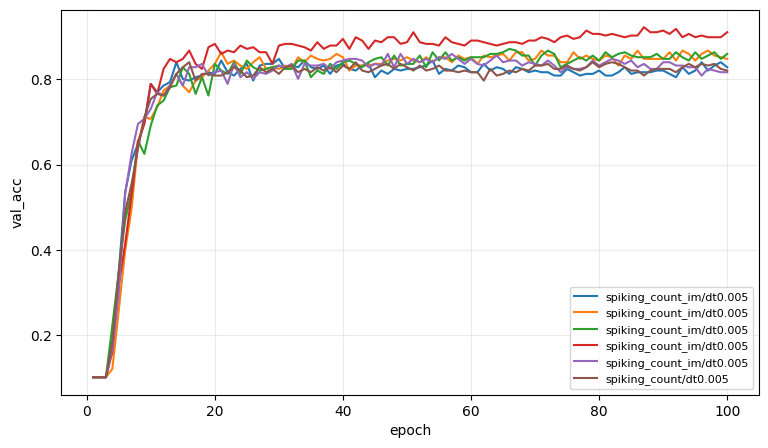

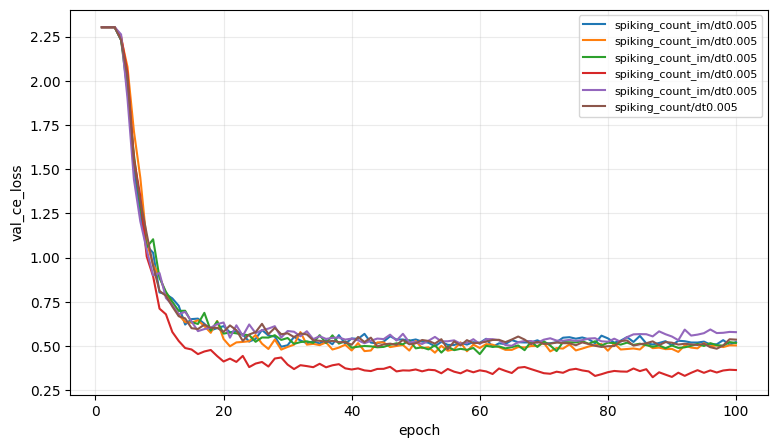

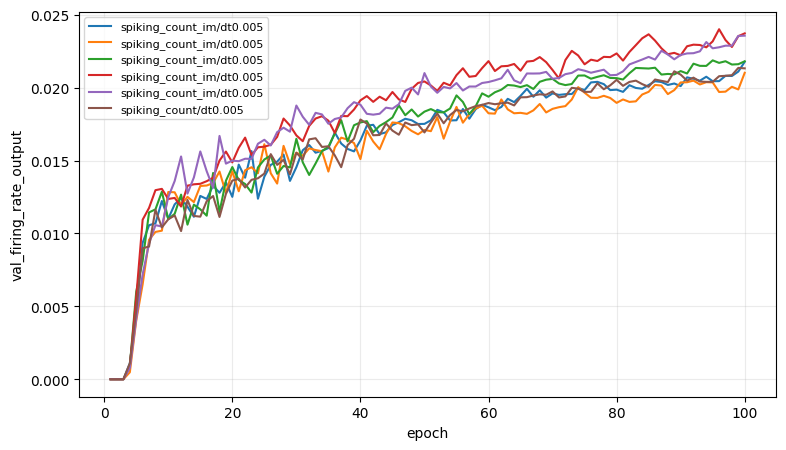

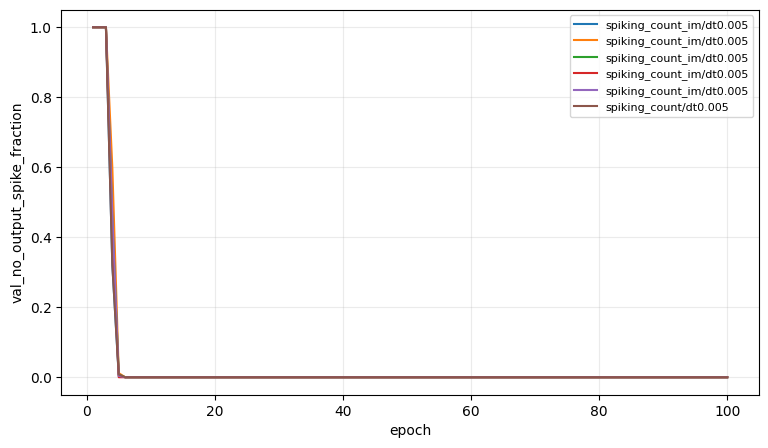

In [11]:
import matplotlib.pyplot as plt


def load_run_frame(run_dir):
    frame = pd.read_csv(Path(run_dir) / "metrics.csv")
    frame["run_dir"] = str(run_dir)
    return frame


def plot_metric_for_runs(run_dirs, metric="val_acc", max_runs=6):
    plt.figure(figsize=(9, 5))
    for run_dir in run_dirs[:max_runs]:
        frame = load_run_frame(run_dir)
        if metric not in frame.columns:
            continue
        label = Path(run_dir).parent.name + "/" + Path(run_dir).name.split("_")[-2]
        plt.plot(frame["epoch"], frame[metric], label=label)
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.show()


plot_metric_for_runs(run_dirs, "val_acc")
plot_metric_for_runs(run_dirs, "val_ce_loss")
plot_metric_for_runs(run_dirs, "val_firing_rate_output")
plot_metric_for_runs(run_dirs, "val_no_output_spike_fraction")


## 10. Output-Layer IM Lambda Sweep

This tests the IM coefficient. It uses spiking output count + output-layer threshold IM by default.

Default grid:

- Lambdas: `0.0, 0.0001, 0.0003, 0.001, 0.003, 0.01`
- Seeds: `2020, 42, 123`

That is 18 tasks. Run after the three-condition comparison looks healthy.

In [11]:
RUN_LAMBDA_SWEEP = True
os.environ["IM_LAMBDAS"] = "0.0,0.0001,0.0003,0.001,0.003,0.01"
os.environ["SEEDS"] = "2020,42,123"
os.environ["LAMBDA_SWEEP_IM_LOSS_TYPE"] = "threshold"

lambda_count = len([x for x in os.environ["IM_LAMBDAS"].split(",") if x.strip()])
seed_count = len([x for x in os.environ["SEEDS"].split(",") if x.strip()])
lambda_task_count = lambda_count * seed_count
print("lambda sweep tasks:", lambda_task_count)
run_task("ff_output_lambda_sweep", 0, dry_run=True)

if RUN_LAMBDA_SWEEP:
    run_tasks("ff_output_lambda_sweep", range(lambda_task_count))
else:
    print("RUN_LAMBDA_SWEEP is False. Set it to True when ready.")


lambda sweep tasks: 18
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 0 --dry-run
Running 18 task(s) for ff_output_lambda_sweep: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 0
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 1
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 2
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 3
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 4
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 5
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 6
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 7
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 8
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 9
$ /usr/bin/python3 scripts/run_temporal_task.py ff_out

## 11. Summarize Lambda Sweep

This selects the lambda with the highest mean validation accuracy and creates accuracy/diagnostic plots.

$ /usr/bin/python3 summarize_lambda_sweep.py --dataset Randman --loss_type threshold --run_root /content/drive/MyDrive/im_snn_runs --output_dir /content/drive/MyDrive/im_snn_runs/summary


,lambda,n,mean_best_val_acc_percent,mean_test_acc_percent,std_test_acc_percent,mean_test_firing_rate_output,mean_test_entropy_output,mean_test_no_output_spike_fraction
0,0.0000,3,84.635417,81.640625,2.343750,0.014557,0.075571,0.0
1,0.0001,3,83.984375,81.380208,0.813151,0.014546,0.075412,0.0
2,0.0003,3,84.505208,82.291667,2.658929,0.013719,0.072052,0.0
3,0.0010,3,82.552083,80.078125,2.706329,0.014966,0.076971,0.0
4,0.0030,3,80.989583,77.343750,3.471951,0.016319,0.082990,0.0
5,0.0100,3,76.432292,77.213542,2.255274,0.018862,0.093208,0.0


,dataset,condition,loss_type,lambda,seed,best_epoch,best_val_acc_percent,test_acc_percent,test_ce_loss,test_im_loss,test_output_im_loss,test_firing_rate_output,test_entropy_output,test_no_output_spike_fraction,test_output_spike_count_mean,test_correct_class_output_spike_count_mean,test_max_competing_output_spike_count_mean,test_correct_output_gt_competing_fraction,run_dir,checkpoint
0,Randman,spiking_count_threshold_im,threshold,0.0000,42,19,87.500000,79.296875,0.648478,10.322989,10.322989,0.015332,0.078770,0.0,15.332031,6.140625,3.480469,0.769531,/content/drive/MyDrive/im_snn_runs/randman/lam...,/content/drive/MyDrive/im_snn_runs/randman/lam...
1,Randman,spiking_count_threshold_im,threshold,0.0000,123,20,83.593750,83.984375,0.577237,11.340387,11.340387,0.013781,0.072368,0.0,13.781250,5.875000,3.089844,0.789062,/content/drive/MyDrive/im_snn_runs/randman/lam...,/content/drive/MyDrive/im_snn_runs/randman/lam...
2,Randman,spiking_count_threshold_im,threshold,0.0000,2020,19,82.812500,81.640625,0.563478,11.748151,11.748151,0.014559,0.075573,0.0,14.558594,6.164062,3.203125,0.777344,/content/drive/MyDrive/im_snn_runs/randman/lam...,/content/drive/MyDrive/im_snn_runs/randman/lam...
3,Randman,spiking_count_threshold_im,threshold,0.0001,42,19,87.890625,80.468750,0.656285,9.638614,9.638614,0.016445,0.083501,0.0,16.445312,6.363281,3.636719,0.750000,/content/drive/MyDrive/im_snn_runs/randman/lam...,/content/drive/MyDrive/im_snn_runs/randman/lam...
4,Randman,spiking_count_threshold_im,threshold,0.0001,123,15,81.640625,81.640625,0.612899,8.716972,8.716972,0.011605,0.062965,0.0,11.605469,4.984375,2.738281,0.761719,/content/drive/MyDrive/im_snn_runs/randman/lam...,/content/drive/MyDrive/im_snn_runs/randman/lam...


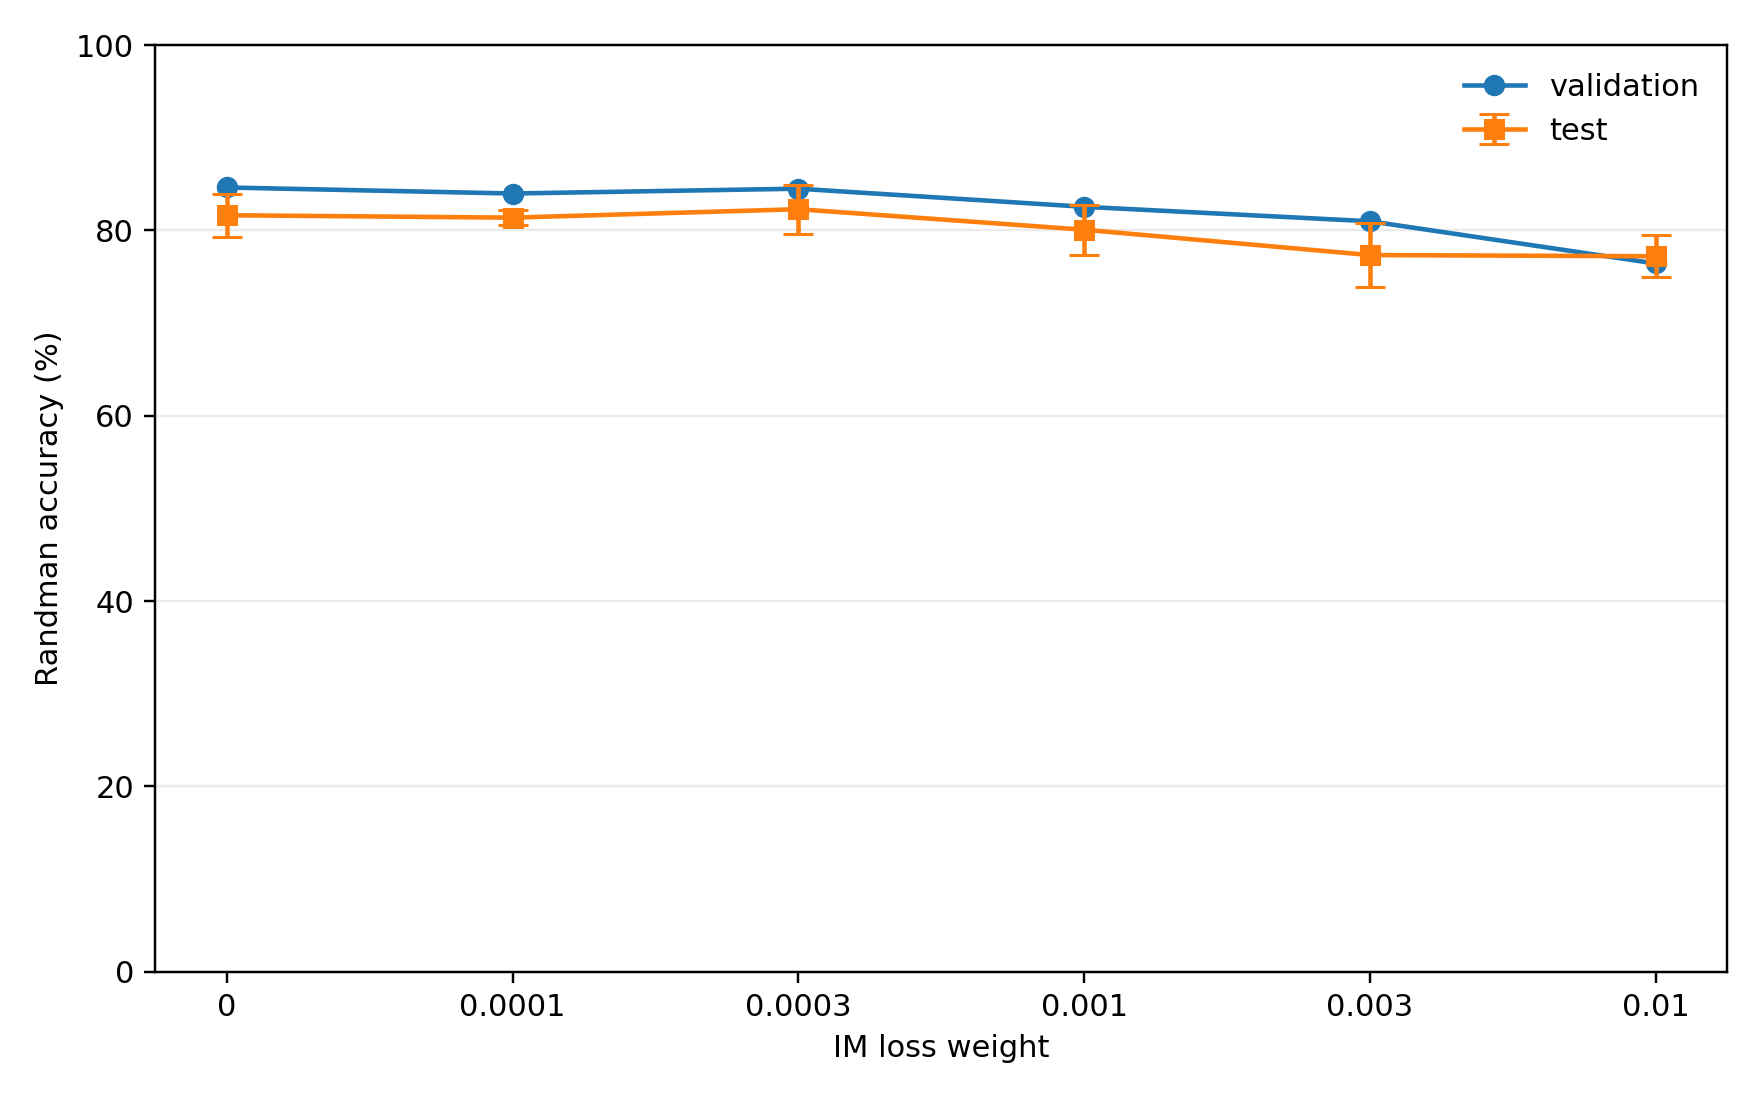

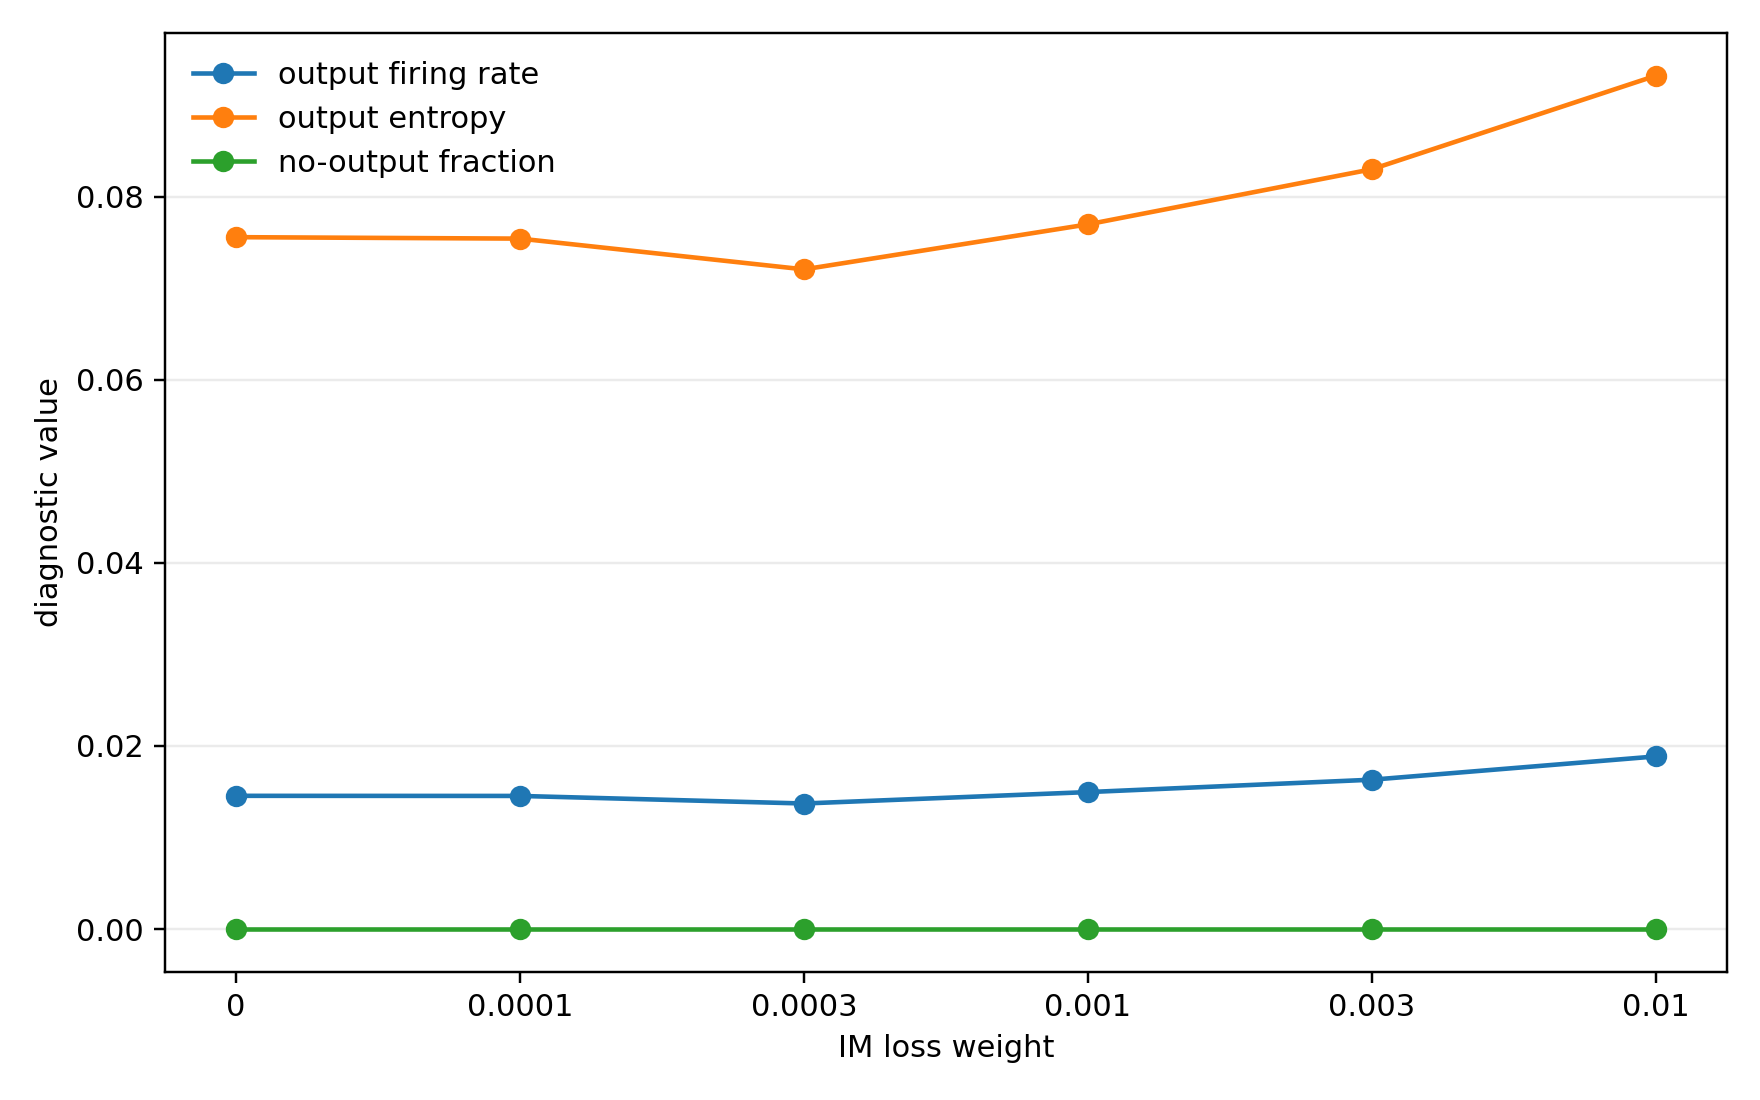

In [14]:
summary_dir = Path(RUNS_ROOT) / "summary"
summary_dir.mkdir(parents=True, exist_ok=True)

if RUN_LAMBDA_SWEEP:
    run([
        sys.executable,
        "summarize_lambda_sweep.py",
        "--dataset", "Randman",
        "--loss_type", os.environ["LAMBDA_SWEEP_IM_LOSS_TYPE"],
        "--run_root", RUNS_ROOT,
        "--output_dir", summary_dir,
    ])

    prefix = f"randman_{os.environ['LAMBDA_SWEEP_IM_LOSS_TYPE']}_lambda_sweep"
    display(read_csv(summary_dir / f"{prefix}_summary.csv"))
    display(read_csv(summary_dir / f"{prefix}_detail.csv").head())
    show_image(summary_dir / f"{prefix}_accuracy.png")
    show_image(summary_dir / f"{prefix}_diagnostics.png")
else:
    print("No lambda summary generated because RUN_LAMBDA_SWEEP is False.")


## 11b. Rate-IM Lambda Sweep To Match The Main Winning Condition
The three-condition comparison uses rate-style output IM. Run a rate-IM lambda sweep as the matched hyperparameter sensitivity analysis, separate from the threshold-IM sweep.

In [15]:
RUN_RATE_LAMBDA_SWEEP = True

os.environ["DATASET"] = "Randman"
os.environ["LAMBDA_SWEEP_IM_LOSS_TYPE"] = "rate"
os.environ["IM_LAMBDAS"] = "0.0,0.0001,0.0003,0.001,0.003,0.01"
os.environ["SEEDS"] = "2020,42,123"

if RUN_RATE_LAMBDA_SWEEP:
    lambda_count = len([x for x in os.environ["IM_LAMBDAS"].split(",") if x.strip()])
    seed_count = len([x for x in os.environ["SEEDS"].split(",") if x.strip()])
    for task_id in range(lambda_count * seed_count):
        run_task("ff_output_lambda_sweep", task_id)

RUN_RATE_LAMBDA_SUMMARY = True
if RUN_RATE_LAMBDA_SUMMARY:
    run([
        sys.executable,
        "summarize_lambda_sweep.py",
        "--dataset", "Randman",
        "--loss_type", "rate",
        "--run_root", RUNS_ROOT,
        "--output_dir", summary_dir,
    ])

$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 0
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 1
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 2
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 3
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 4
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 5
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 6
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 7
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 8
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 9
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 10
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 11
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 12
$ /usr/bin/python3 scripts/run_temporal_task.py 

## 11c. Best-Vs-Worst Lambda Per-Epoch Diagnostics
Use the lambda sweep summaries to compare the best and worst lambda over training. These plots connect performance to output firing rate, entropy, IM loss, and correct-vs-competing spike evidence.

lambda detail: /content/drive/MyDrive/im_snn_runs/summary/randman_rate_lambda_sweep_detail.csv
best lambda: 0.01 worst lambda: 0.003


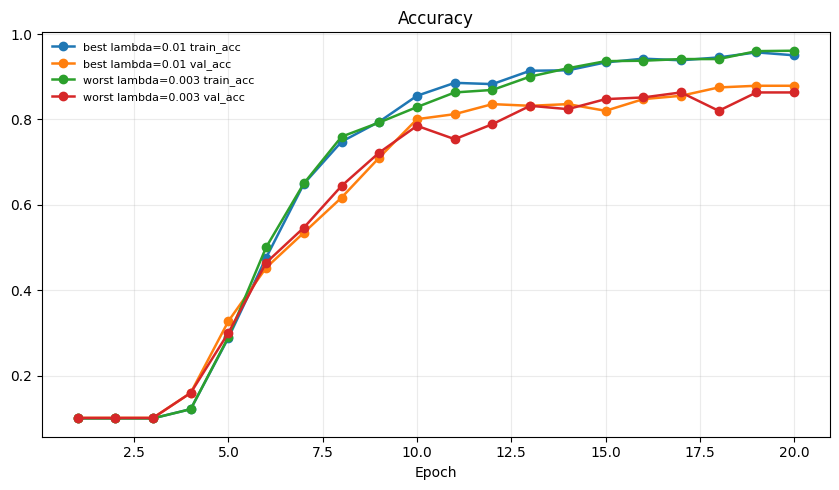

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_accuracy.png


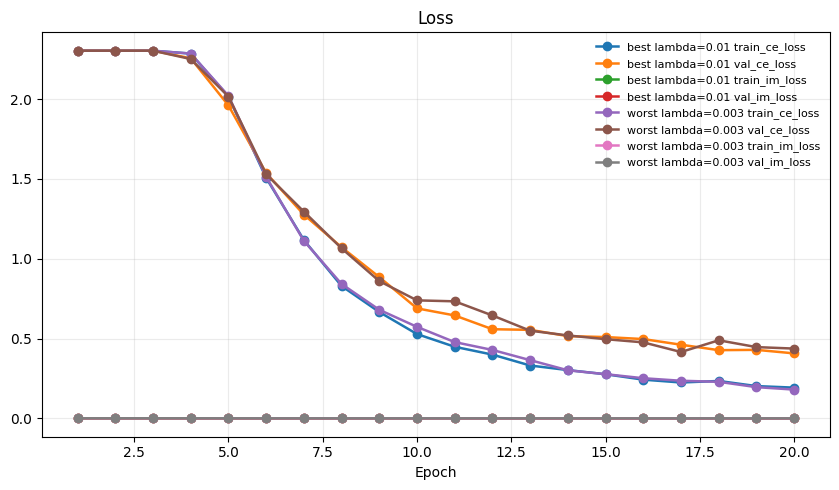

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_loss.png


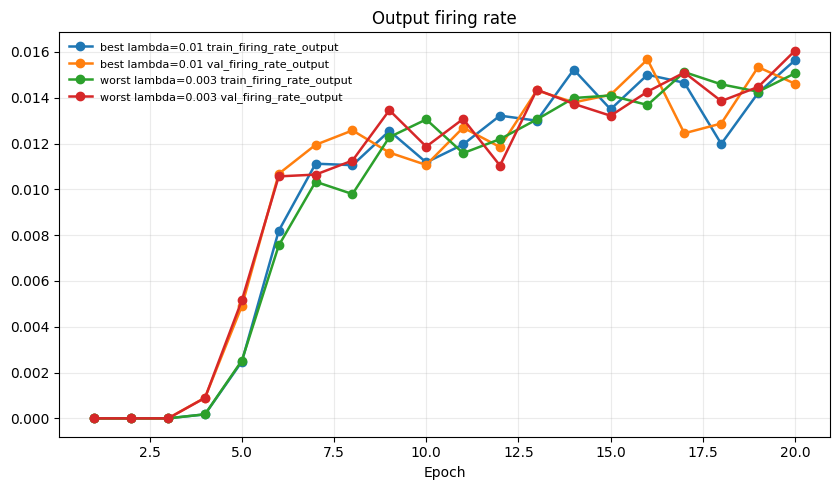

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_output_firing.png


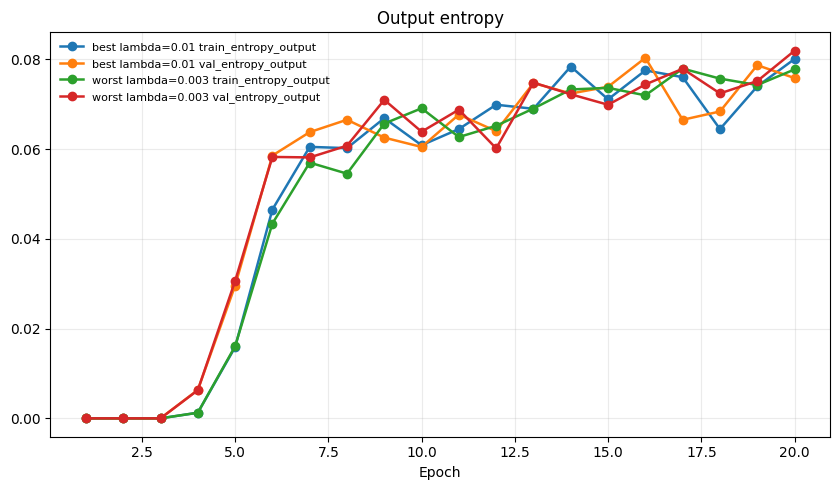

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_output_entropy.png


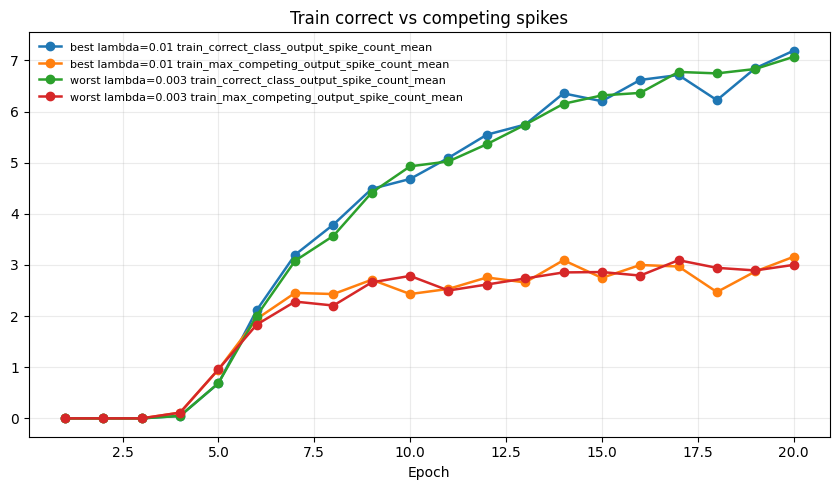

wrote /content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_correct_vs_competing.png


In [19]:
import csv
import math
from statistics import mean

import matplotlib.pyplot as plt


def read_csv_rows(path):
    path = Path(path)
    if not path.exists():
        print("missing:", path)
        return []
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))


def to_float(value, default=math.nan):
    try:
        if value == "" or value is None:
            return default
        return float(value)
    except (TypeError, ValueError):
        return default


def save_current_figure(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.show()
    print("wrote", path)

def read_lambda_detail(dataset="Randman", loss_type="rate"):
    detail_path = summary_dir / f"{dataset.lower()}_{loss_type}_lambda_sweep_detail.csv"
    rows = read_csv_rows(detail_path)
    if not rows:
        return [], detail_path
    return rows, detail_path


def load_metrics_csv(run_dir):
    path = Path(run_dir) / "metrics.csv"
    rows = read_csv_rows(path)
    return path, rows


def pick_best_and_worst_lambda(rows):
    by_lambda = {}
    for row in rows:
        by_lambda.setdefault(row["lambda"], []).append(row)
    scored = []
    for lam, lam_rows in by_lambda.items():
        vals = [to_float(row["best_val_acc_percent"]) for row in lam_rows]
        vals = [v for v in vals if not math.isnan(v)]
        if vals:
            scored.append((mean(vals), lam))
    if not scored:
        return None, None
    scored.sort()
    return scored[-1][1], scored[0][1]


lambda_rows, lambda_detail_path = read_lambda_detail("Randman", os.environ.get("LAMBDA_SWEEP_IM_LOSS_TYPE", "rate"))
print("lambda detail:", lambda_detail_path)

if lambda_rows:
    best_lambda, worst_lambda = pick_best_and_worst_lambda(lambda_rows)
    print("best lambda:", best_lambda, "worst lambda:", worst_lambda)

    selected = []
    for label, lam in [("best", best_lambda), ("worst", worst_lambda)]:
        candidates = [row for row in lambda_rows if row["lambda"] == lam]
        candidates.sort(key=lambda row: to_float(row["best_val_acc_percent"]), reverse=True)
        if candidates:
            selected.append((label, lam, candidates[0]))

    metric_groups = [
        (["train_acc", "val_acc"], "Accuracy", "accuracy"),
        (["train_ce_loss", "val_ce_loss", "train_im_loss", "val_im_loss"], "Loss", "loss"),
        (["train_firing_rate_output", "val_firing_rate_output"], "Output firing rate", "output_firing"),
        (["train_entropy_output", "val_entropy_output"], "Output entropy", "output_entropy"),
        (["train_correct_class_output_spike_count_mean", "train_max_competing_output_spike_count_mean"], "Train correct vs competing spikes", "correct_vs_competing"),
    ]

    for keys, title, file_tag in metric_groups:
        plt.figure(figsize=(8.5, 5.0))
        plotted = False
        for label, lam, row in selected:
            metrics_path, metrics_rows = load_metrics_csv(row["run_dir"])
            if not metrics_rows:
                print("missing metrics:", metrics_path)
                continue
            epochs = [int(to_float(r.get("epoch"), i + 1)) for i, r in enumerate(metrics_rows)]
            for key in keys:
                values = [to_float(r.get(key)) for r in metrics_rows]
                if all(math.isnan(v) for v in values):
                    continue
                plotted = True
                plt.plot(epochs, values, marker="o", linewidth=1.8, label=f"{label} lambda={lam} {key}")
        if plotted:
            plt.title(title)
            plt.xlabel("Epoch")
            plt.grid(alpha=0.25)
            plt.legend(frameon=False, fontsize=8)
            save_current_figure(summary_dir / f"randman_lambda_best_worst_{file_tag}.png")
        else:
            plt.close()
else:
    print("Run and summarize the lambda sweep first.")

## 11d. Final Randman Robustness Run
Use the existing five-seed three-condition grid as the main robust result. A ten-seed rerun can be added later, but the current task runner already supports the project-plan target of 3 to 5 seeds.

In [20]:
RUN_FINAL_RANDMAN_FIVE_SEED = True

if RUN_FINAL_RANDMAN_FIVE_SEED:
    os.environ["DATASET"] = "Randman"
    os.environ["READOUT"] = "max_membrane"
    for task_id in range(15):
        run_task("ff_output_3way", task_id)

# Re-run the summary after the robustness grid finishes.
if RUN_FINAL_RANDMAN_FIVE_SEED:
    run([
        sys.executable,
        "summarize_ff_output_3way.py",
        "--dataset", "Randman",
        "--run_root", RUNS_ROOT,
        "--output_dir", summary_dir,
    ])

$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 0
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 1
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 2
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 3
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 4
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 5
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 6
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 7
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 8
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 9
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 10
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 11
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 12
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 13
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 14
$ /usr/bin/python3 s

## 11e. Final Randman Figure Inventory
List the CSV and PNG artifacts that should be copied into the final report or slides. These are generated from saved run artifacts, so figures are reproducible.

In [21]:
figure_patterns = [
    "randman_ff_output_3way*.csv",
    "randman_ff_output_3way*.png",
    "randman_*lambda_sweep*.csv",
    "randman_*lambda_sweep*.png",
    "randman_report_*.png",
    "randman_lambda_best_worst_*.png",
]

for pattern in figure_patterns:
    matches = sorted(summary_dir.glob(pattern))
    print(f"\n{pattern}")
    for path in matches:
        print(" -", path)


randman_ff_output_3way*.csv
 - /content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_summary.csv
 - /content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_test_eval.csv

randman_ff_output_3way*.png
 - /content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_hist.png

randman_*lambda_sweep*.csv
 - /content/drive/MyDrive/im_snn_runs/summary/randman_rate_lambda_sweep_detail.csv
 - /content/drive/MyDrive/im_snn_runs/summary/randman_rate_lambda_sweep_summary.csv
 - /content/drive/MyDrive/im_snn_runs/summary/randman_threshold_lambda_sweep_detail.csv
 - /content/drive/MyDrive/im_snn_runs/summary/randman_threshold_lambda_sweep_summary.csv

randman_*lambda_sweep*.png
 - /content/drive/MyDrive/im_snn_runs/summary/randman_rate_lambda_sweep_accuracy.png
 - /content/drive/MyDrive/im_snn_runs/summary/randman_rate_lambda_sweep_diagnostics.png
 - /content/drive/MyDrive/im_snn_runs/summary/randman_threshold_lambda_sweep_accuracy.png
 - /content/drive/MyDrive/im_snn_runs

## 12. SHD Data Setup

SHD is the stretch benchmark. Randman needs no data files because samples are generated by code. SHD is a real dataset and must be stored outside Git.

Expected Drive files:

```text
/content/drive/MyDrive/datasets/SHD/shd_train.h5
/content/drive/MyDrive/datasets/SHD/shd_test.h5
```

If they are missing, the next cell can download the compressed SHD files and decompress them. Skip SSC for this project unless you explicitly extend the repo later.

In [7]:
SHD_ROOT = Path("/content/drive/MyDrive/datasets/SHD")
SHD_ROOT.mkdir(parents=True, exist_ok=True)

DOWNLOAD_SHD = False
if DOWNLOAD_SHD:
    run(["wget", "-nc", "https://compneuro.net/datasets/shd_train.h5.gz", "-P", SHD_ROOT])
    run(["wget", "-nc", "https://compneuro.net/datasets/shd_test.h5.gz", "-P", SHD_ROOT])
    for name in ["shd_train.h5", "shd_test.h5"]:
        if not (SHD_ROOT / name).exists():
            run(["gunzip", "-k", str(SHD_ROOT / f"{name}.gz")])

print("SHD root:", SHD_ROOT)
print("train exists:", (SHD_ROOT / "shd_train.h5").exists())
print("test exists:", (SHD_ROOT / "shd_test.h5").exists())
print("files:", [path.name for path in sorted(SHD_ROOT.glob("shd_*"))])


SHD root: /content/drive/MyDrive/datasets/SHD
train exists: True
test exists: True
files: ['shd_test.h5', 'shd_test.h5.zip', 'shd_train.h5', 'shd_train.h5.zip']


## 13. SHD Smoke Test And Optional Runs

Only run this after `shd_train.h5` and `shd_test.h5` exist. Start with one batch. Then run one seed. Then consider the full SHD grid if Colab runtime allows.

In [8]:
RUN_SHD_ONE_BATCH = True

if RUN_SHD_ONE_BATCH:
    if not (SHD_ROOT / "shd_train.h5").exists() or not (SHD_ROOT / "shd_test.h5").exists():
        raise FileNotFoundError("SHD files are missing. Run the SHD download/setup cell first.")

    run([
        sys.executable,
        "train_temporal.py",
        "--dataset", "SHD",
        "--data_root", SHD_ROOT,
        "--output_dir", str(Path(RUNS_ROOT) / "_checks" / "quick_shd"),
        "--epochs", "1",
        "--max_train_batches", "1",
        "--max_eval_batches", "1",
        "--num_workers", "0",
    ])
else:
    print("RUN_SHD_ONE_BATCH is False. Enable it after SHD files are ready.")


$ /usr/bin/python3 train_temporal.py --dataset SHD --data_root /content/drive/MyDrive/datasets/SHD --output_dir /content/drive/MyDrive/im_snn_runs/_checks/quick_shd --epochs 1 --max_train_batches 1 --max_eval_batches 1 --num_workers 0


In [9]:
RUN_SHD_THREE_WAY = True
FULL_SHD_THREE_WAY = True

if RUN_SHD_THREE_WAY:
    os.environ.update({
        "DATASET": "SHD",
        "DATA_ROOT": str(SHD_ROOT),
        "EPOCHS": "20",
        "BATCH_SIZE": "64",
        "NUM_WORKERS": "2",
    })
    shd_tasks = range(15) if FULL_SHD_THREE_WAY else [0, 5, 10]
    run_tasks("ff_output_3way", shd_tasks)
else:
    print("RUN_SHD_THREE_WAY is False. Randman should be completed first.")


Running 15 task(s) for ff_output_3way: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 0
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 1
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 2
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 3
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 4
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 5
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 6
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 7
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 8
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 9
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 10
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 11
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way 12
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_3way

## 14. Summarize SHD Three-Condition Runs

Use this after SHD three-way runs finish. For quick one-seed SHD checks, allow partial summaries. For final results, use full multi-seed summaries.

$ /usr/bin/python3 summarize_ff_output_3way.py --dataset SHD --run_root /content/drive/MyDrive/im_snn_runs --output_dir /content/drive/MyDrive/im_snn_runs/summary


,setting,setting_label,n,mean_test_acc_percent,std_test_acc_percent,min_test_acc_percent,max_test_acc_percent,seed_test_acc_percent
0,lif_mlp_noim,Non-spiking membrane,5,38.462898,2.991395,34.893993,42.181979,42.1820;34.8940;40.1060;39.1343;35.9982
1,spiking_count,Spiking output count,5,59.381625,2.392428,56.051237,61.572438,56.0512;57.9064;61.5724;61.5283;59.8498
2,spiking_count_im,Spiking output count + IM,5,57.738516,3.013488,53.754417,61.351590,58.8339;53.7544;55.6537;59.0989;61.3516


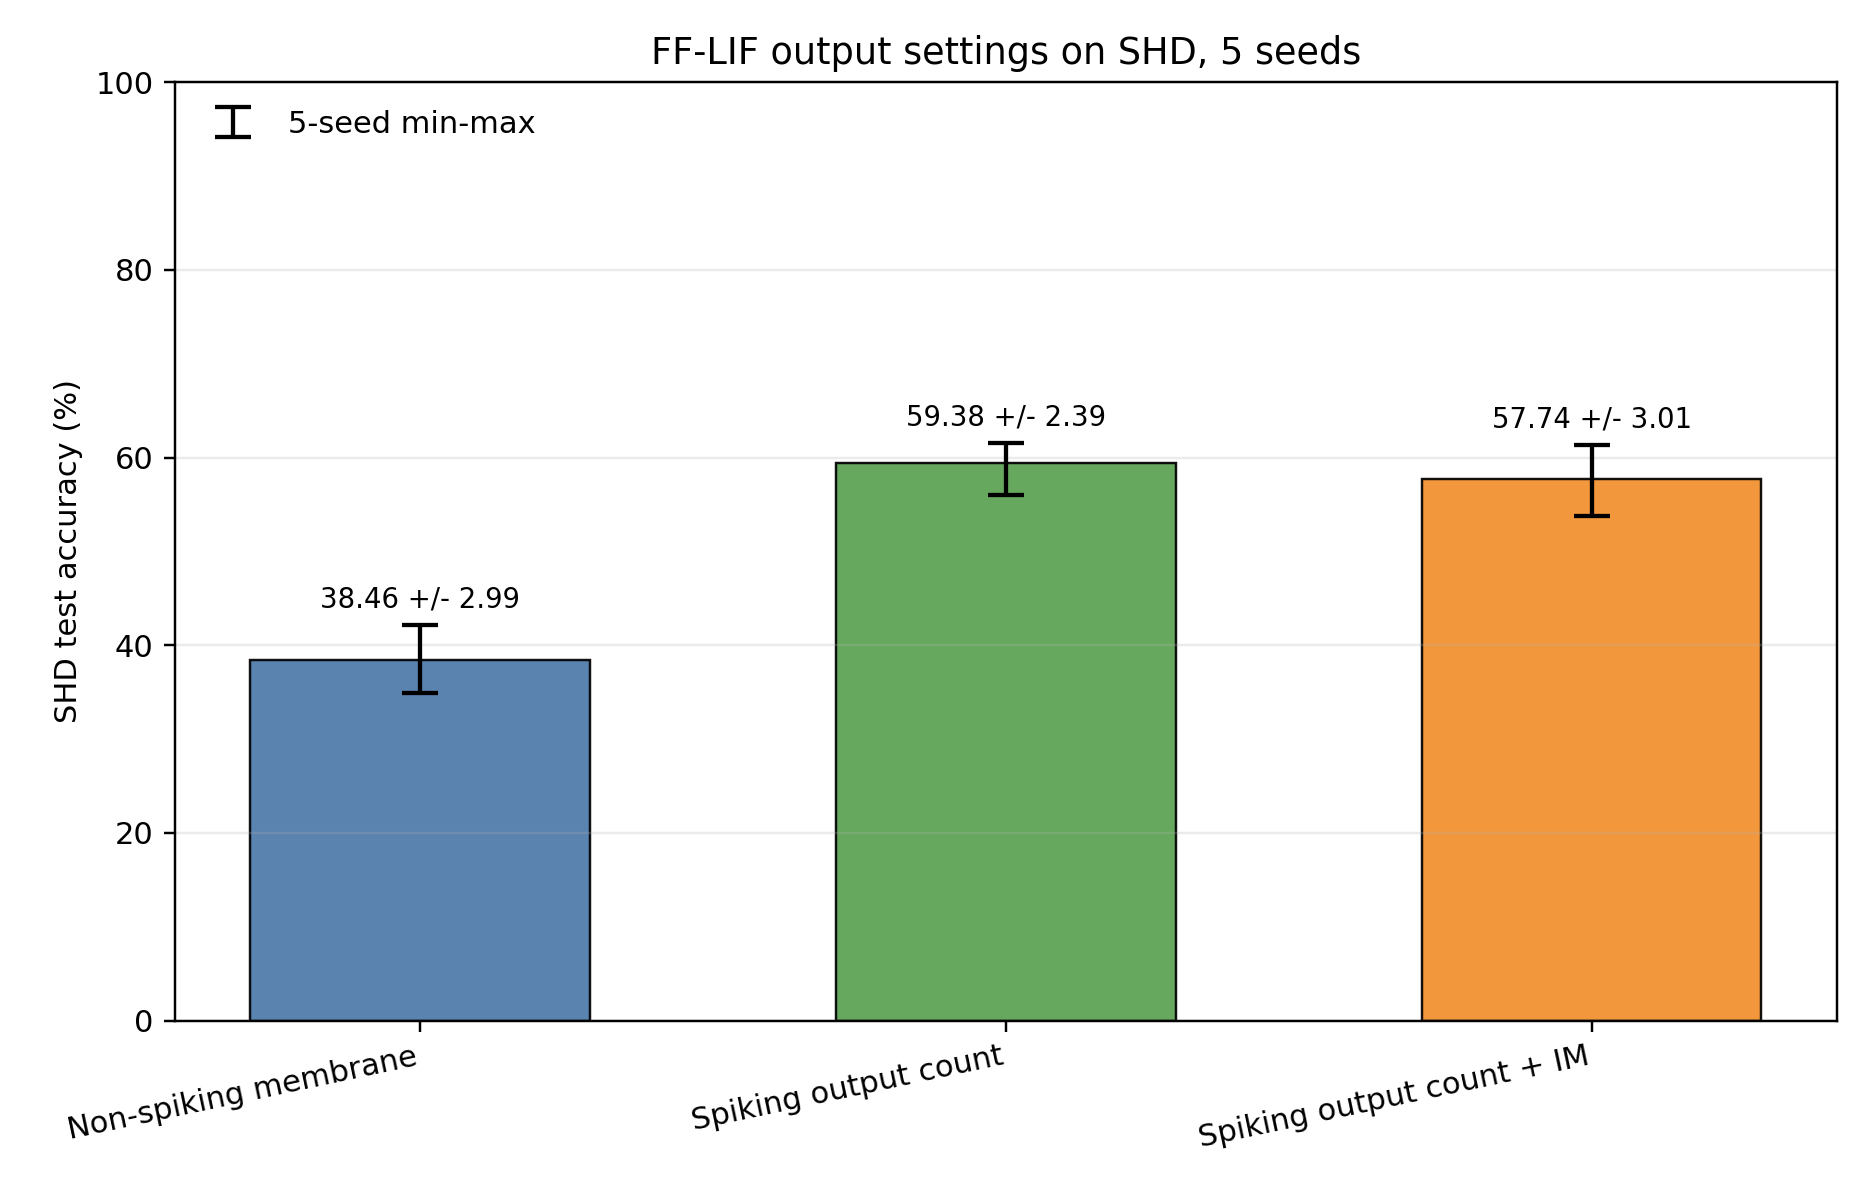

In [11]:
RUN_SHD_SUMMARY = True

summary_dir = Path(RUNS_ROOT) / "summary"
summary_dir.mkdir(parents=True, exist_ok=True)

if RUN_SHD_SUMMARY:
    shd_summary_cmd = [
        sys.executable,
        "summarize_ff_output_3way.py",
        "--dataset", "SHD",
        "--run_root", RUNS_ROOT,
        "--output_dir", summary_dir,
    ]
    if not FULL_SHD_THREE_WAY:
        shd_summary_cmd.append("--allow_partial")
    run(shd_summary_cmd)
    display(read_csv(summary_dir / "shd_ff_output_3way_summary.csv"))
    show_image(summary_dir / "shd_ff_output_3way_hist.png")
else:
    print("RUN_SHD_SUMMARY is False.")


## 14b. SHD Lambda Sweep Stretch Run
Run this only after Randman results are complete. SHD is slower, so the sweep uses fewer lambdas and seeds by default.

In [12]:
RUN_SHD_LAMBDA_SWEEP = True
RUN_SHD_LAMBDA_SUMMARY = True

if RUN_SHD_LAMBDA_SWEEP:
    os.environ["DATASET"] = "SHD"
    os.environ["DATA_ROOT"] = str(SHD_ROOT)
    os.environ["LAMBDA_SWEEP_IM_LOSS_TYPE"] = "rate"
    os.environ["IM_LAMBDAS"] = "0.0,0.0003,0.001,0.003"
    os.environ["SEEDS"] = "2020,42,123"

    lambda_count = len([x for x in os.environ["IM_LAMBDAS"].split(",") if x.strip()])
    seed_count = len([x for x in os.environ["SEEDS"].split(",") if x.strip()])
    for task_id in range(lambda_count * seed_count):
        run_task("ff_output_lambda_sweep", task_id)

if RUN_SHD_LAMBDA_SUMMARY:
    run([
        sys.executable,
        "summarize_lambda_sweep.py",
        "--dataset", "SHD",
        "--loss_type", "rate",
        "--run_root", RUNS_ROOT,
        "--output_dir", summary_dir,
    ])

$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 0
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 1
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 2
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 3
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 4
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 5
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 6
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 7
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 8
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 9
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 10
$ /usr/bin/python3 scripts/run_temporal_task.py ff_output_lambda_sweep 11
$ /usr/bin/python3 summarize_lambda_sweep.py --dataset SHD --loss_type rate --run_root /content/drive/MyDrive/im_snn_runs 

## 15. Result Files To Keep

Main result files are under `RUNS_ROOT` in Drive.

Per run:

- `config.json`: full run configuration.
- `metrics.csv`: per-epoch train/validation curves and diagnostics.
- `best.pth`: best validation checkpoint.
- `last.pth`: final checkpoint.
- `metrics.json`: final test metrics from the best checkpoint.

Summary folder:

- `*_summary.csv`: aggregated accuracy table.
- `*_test_eval.csv` or `*_detail.csv`: per-seed details.
- `*.png`: plots for report figures.

For final reporting, prefer multi-seed mean and standard deviation, not one-seed results.

In [13]:
print("RUNS_ROOT contents:")
for path in sorted(Path(RUNS_ROOT).glob("*")):
    print(path)

print("\nSummary contents:")
if summary_dir.exists():
    for path in sorted(summary_dir.glob("*")):
        print(path)


RUNS_ROOT contents:
/content/drive/MyDrive/im_snn_runs/_checks
/content/drive/MyDrive/im_snn_runs/randman
/content/drive/MyDrive/im_snn_runs/shd
/content/drive/MyDrive/im_snn_runs/summary

Summary contents:
/content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_hist.png
/content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_summary.csv
/content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_summary.json
/content/drive/MyDrive/im_snn_runs/summary/randman_ff_output_3way_test_eval.csv
/content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_accuracy.png
/content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_correct_vs_competing.png
/content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_loss.png
/content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_output_entropy.png
/content/drive/MyDrive/im_snn_runs/summary/randman_lambda_best_worst_output_firing.png
/content/drive/MyDrive/im_snn_runs/summary/randman_r